# Does It Rain More in Seattle Than in Miami?

## Introduction

Seattle has a reputation for being one of the rainiest cities in the United States. A lot of people picture gray skies and drizzle for most of the year. Miami, on the other hand, is known for sunshine and beaches, so most people would probably guess that it rains less there.

In this project I use daily weather data from 2018 to 2022 to check whether it actually rains more in Seattle than in Miami. I look at the question in two ways. First, I compare the amount of precipitation in each city. Second, I compare how often it rains, meaning the proportion of days that had any precipitation. These two things do not have to agree, since a city could have a lot of light rainy days or a smaller number of very heavy ones.

To answer the question I follow the data science methodology. I start by collecting and cleaning the data, then I explore it with graphs and summaries, and finally I use statistical tests to compare the two cities.

## Data Source

The data come from the National Oceanic and Atmospheric Administration (NOAA). I downloaded daily weather summaries from NOAA's Climate Data Online website: https://www.ncei.noaa.gov/cdo-web/

I used two weather stations, one for each city:

- Seattle: Seattle-Tacoma International Airport (station ID USW00024233)
- Miami: Miami International Airport (station ID USW00012839)

The data cover January 1, 2018 to December 31, 2022. The downloaded file is saved in the data folder of my GitHub repository: https://github.com/rockgignac/weather/blob/main/data/4406076.csv

The column I am most interested in is `PRCP`, which is the daily precipitation in inches. The file also has snowfall (`SNOW`) and snow depth (`SNWD`) columns, but I do not need those to answer my question.

## Importing Libraries

First I import the libraries used in this notebook. I use pandas and numpy to work with the data, matplotlib and seaborn to make graphs, and scipy and statsmodels for the statistical tests. Used AI to find the appropriate models


In [10]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_style("whitegrid")

## Loading the Data

Both weather stations were downloaded together in one CSV file. I read the file straight from my GitHub repository so that anyone can run this notebook.

In [14]:
weather = pd.read_csv("https://github.com/rockgignac/weather/blob/main/data/4406076.csv?raw=true")

weather.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00012839,"MIAMI INTERNATIONAL AIRPORT, FL US",2018-01-01,0.00,NaN,NaN
1,USW00012839,"MIAMI INTERNATIONAL AIRPORT, FL US",2018-01-02,0.24,NaN,NaN
2,USW00012839,"MIAMI INTERNATIONAL AIRPORT, FL US",2018-01-03,0.50,NaN,NaN
3,USW00012839,"MIAMI INTERNATIONAL AIRPORT, FL US",2018-01-04,0.00,NaN,NaN
4,USW00012839,"MIAMI INTERNATIONAL AIRPORT, FL US",2018-01-05,0.00,NaN,NaN


Each row is one day at one weather station. The columns are the station ID, station name, date, precipitation, snowfall, and snow depth.

## Inspecting the Data

Next I look at the size of the data set and the data type of each column.

In [16]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  3652 non-null   object 
 1   NAME     3652 non-null   object 
 2   DATE     3652 non-null   object 
 3   PRCP     3649 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.3+ KB


There are 3,652 rows and 6 columns. The `DATE` column is stored as text instead of as a date, so I will need to convert it. The `PRCP` column has 3,649 non-null values out of 3,652, which means 3 precipitation values are missing.

Now I split the data into a separate data frame for each city using the station IDs.

In [18]:
df_seattle = weather[weather["STATION"] == "USW00024233"].copy()
df_miami = weather[weather["STATION"] == "USW00012839"].copy()

print("Seattle:", df_seattle.shape)
print("Miami:", df_miami.shape)

Seattle: (1826, 6)
Miami: (1826, 6)


Each city has 1,826 rows. There are 1,826 days from 2018 through 2022 (365 days times 5 years, plus one extra day for the 2020 leap year), so each city has one row for every day.

I check that each data frame only has one station and look at the first and last dates.

In [20]:
print("Seattle stations:", df_seattle["STATION"].nunique())
print("Miami stations:", df_miami["STATION"].nunique())

print("Seattle dates:", df_seattle["DATE"].min(), "to", df_seattle["DATE"].max())
print("Miami dates:", df_miami["DATE"].min(), "to", df_miami["DATE"].max())

Seattle stations: 1
Miami stations: 1
Seattle dates: 2018-01-01 to 2022-12-31
Miami dates: 2018-01-01 to 2022-12-31


Each data frame has only one station, and both cities cover January 1, 2018 to December 31, 2022. This means there are no dates outside the range I want, so I do not need to remove any.

## Cleaning the Data

### Converting the date column

I convert `DATE` from text to a datetime type so pandas treats it as a date.

In [22]:
df_seattle["DATE"] = pd.to_datetime(df_seattle["DATE"])
df_miami["DATE"] = pd.to_datetime(df_miami["DATE"])

df_seattle.dtypes

STATION            object
NAME               object
DATE       datetime64[ns]
PRCP              float64
SNOW              float64
SNWD              float64
dtype: object

The `DATE` column is now a datetime. `PRCP` was already stored as a number (`float64`), so it does not need to change.

### Checking for duplicates

Next I check whether any dates show up more than once in either city.

In [24]:
print("Seattle duplicate dates:", df_seattle["DATE"].duplicated().sum())
print("Miami duplicate dates:", df_miami["DATE"].duplicated().sum())

Seattle duplicate dates: 0
Miami duplicate dates: 0


Neither city has any duplicate dates, so there is nothing to remove.

### Finding missing values

I count the missing precipitation values in each city.

In [26]:
print("Seattle missing precipitation:", df_seattle["PRCP"].isna().sum())
print("Miami missing precipitation:", df_miami["PRCP"].isna().sum())

df_seattle[df_seattle["PRCP"].isna()]

Seattle missing precipitation: 3
Miami missing precipitation: 0


,STATION,NAME,DATE,PRCP,SNOW,SNWD
3273,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2021-12-18,NaN,0.0,0.0
3283,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2021-12-28,NaN,1.0,2.0
3285,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2021-12-30,NaN,3.4,3.1


Miami does not have any missing values. Seattle has 3 missing precipitation values, on December 18, 28, and 30 of 2021. Snowfall was recorded on December 28 and 30, so there was precipitation on those days even though the precipitation value is missing. Instead of removing these days, I will fill them in after joining the two cities together.

## Joining the Data

I join the Miami and Seattle data frames on the date. I only keep the date and precipitation columns since those are all I need for my question.

In [28]:
df = df_miami[["DATE", "PRCP"]].merge(df_seattle[["DATE", "PRCP"]], on="DATE", how="outer")

df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.24,0.00
2,2018-01-03,0.50,0.00
3,2018-01-04,0.00,0.13
4,2018-01-05,0.00,0.51


The joined data frame has one row for each date. Since both data frames had a column named `PRCP`, pandas renamed them `PRCP_x` for Miami (the first data frame) and `PRCP_y` for Seattle.

### Making the data tidy

The data is in a wide format right now, with a separate column for each city. I use melt to change it to a long (tidy) format, where every row is one city on one date.

In [30]:
df = pd.melt(df, id_vars="DATE", var_name="city", value_name="precipitation")

df.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.24
2,2018-01-03,PRCP_x,0.50
3,2018-01-04,PRCP_x,0.00
4,2018-01-05,PRCP_x,0.00


Now there is a `city` column and a `precipitation` column. The `city` column still says `PRCP_x` and `PRCP_y`, so I need to replace those with the city names.

### Renaming

I change `PRCP_x` to `MIA` and `PRCP_y` to `SEA`. I also rename `DATE` to `date` so that all of the column names are lowercase.

In [32]:
df.loc[df["city"] == "PRCP_x", "city"] = "MIA"
df.loc[df["city"] == "PRCP_y", "city"] = "SEA"

df = df.rename(columns={"DATE": "date"})

print(df.shape)
df.head()

(3652, 3)


,date,city,precipitation
0,2018-01-01,MIA,0.00
1,2018-01-02,MIA,0.24
2,2018-01-03,MIA,0.50
3,2018-01-04,MIA,0.00
4,2018-01-05,MIA,0.00


The data frame now has 3 columns, `date`, `city`, and `precipitation`, and 3,652 rows (1,826 days for each city).

## Filling In Missing Values

To fill in the 3 missing Seattle values, I add a `day_of_year` column (1 to 366) and calculate the average precipitation in Seattle for each day of the year across the five years. First I plot these averages to see what they look like.

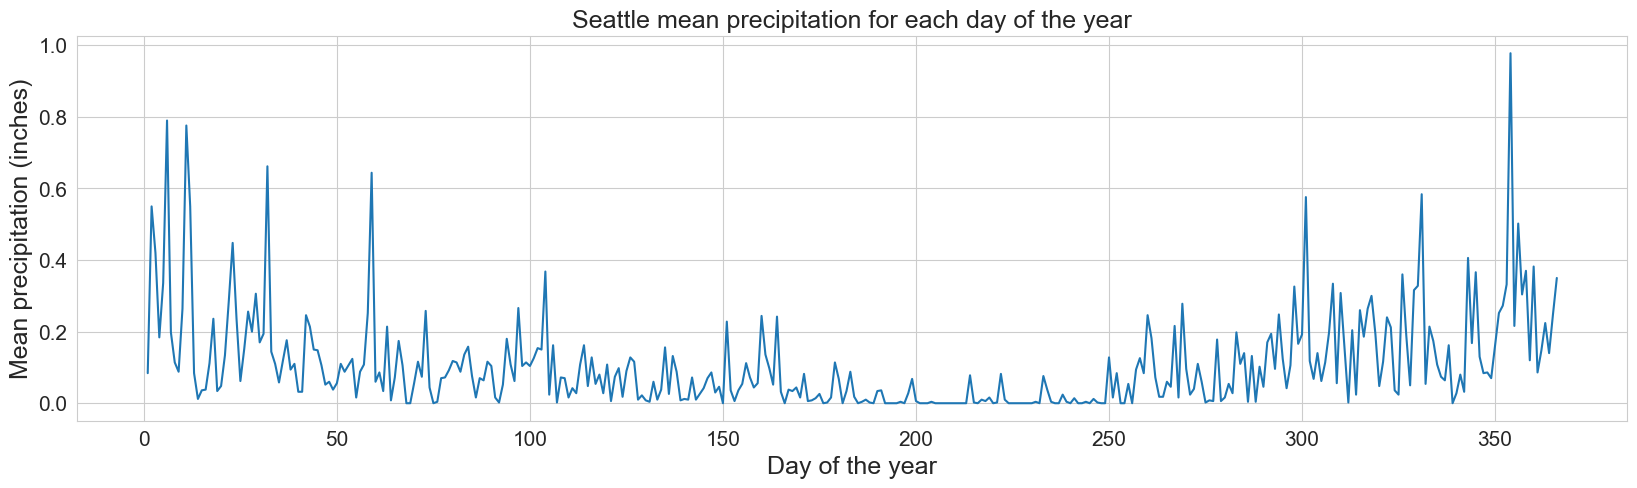

In [34]:
df["day_of_year"] = df["date"].dt.dayofyear

mean_day_precipitation = df.loc[
    df["city"] == "SEA",
    ["precipitation", "day_of_year"]
].groupby("day_of_year").mean()

plt.figure(figsize=(20, 5))
sns.lineplot(data=mean_day_precipitation, x="day_of_year", y="precipitation")
plt.xlabel("Day of the year", fontsize=18)
plt.ylabel("Mean precipitation (inches)", fontsize=18)
plt.title("Seattle mean precipitation for each day of the year", fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

The plot shows that Seattle usually gets more rain at the beginning and end of the year (winter) and very little in the middle of the year (summer). Since each day only has five values to average, the line jumps around a lot, but the seasonal pattern is still clear.

Now I replace each missing value with the average for that city on the same day of the year.

In [36]:
day_of_year_mean = df.groupby(["city", "day_of_year"])["precipitation"].transform("mean")
missing = df["precipitation"].isna()

df["precipitation"] = df["precipitation"].fillna(day_of_year_mean)

print("Missing values left:", df["precipitation"].isna().sum())
df[missing]

Missing values left: 0


,date,city,precipitation,day_of_year
3273,2021-12-18,SEA,0.2725,352
3283,2021-12-28,SEA,0.1475,362
3285,2021-12-30,SEA,0.1400,364


All 3 missing values have been filled in with values between about 0.14 and 0.27 inches, which seem reasonable for Seattle in December. There are no missing values left. Only 3 out of 3,652 values were filled in, so this should not have much effect on the results.

## Saving the Clean Data

I save the clean data set to a CSV file in the data folder.

In [38]:
df.to_csv("data/clean_seattle_miami_precipitation.csv", index=False)

## Exploring the Data

Now that the data is clean, I make some graphs and summaries to understand the data and start answering my question.

### Precipitation over time

I start by plotting the daily precipitation for both cities over the whole time period, using a different color for each city.

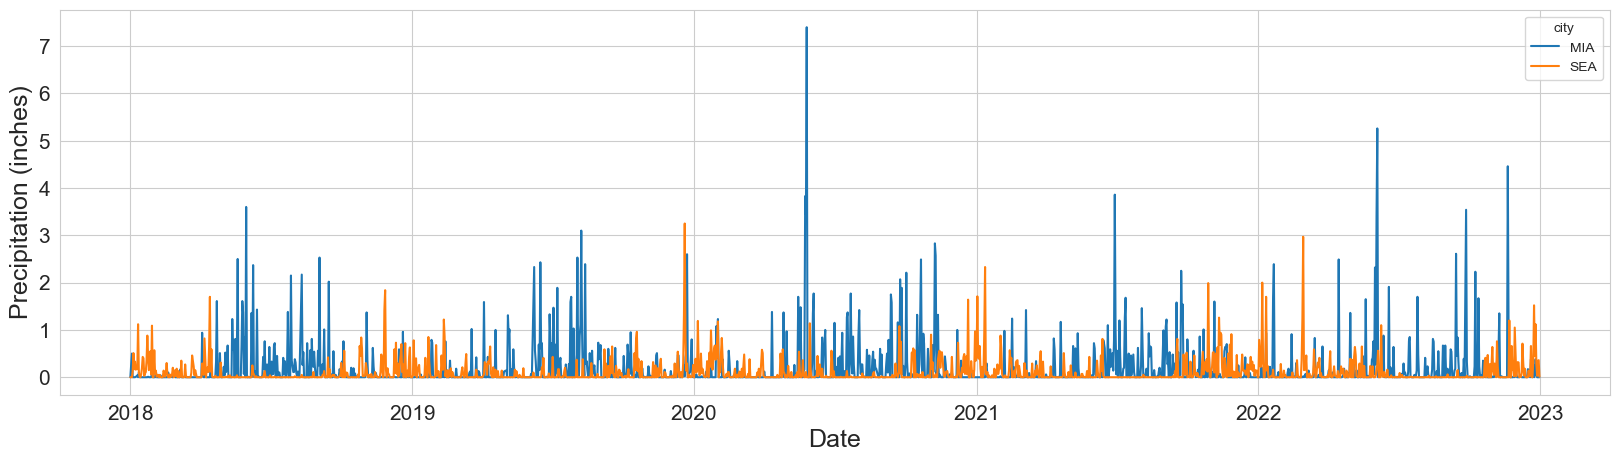

In [44]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df, x="date", y="precipitation", hue="city")
plt.xlabel("Date", fontsize=18)
plt.ylabel("Precipitation (inches)", fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

This plot shows the raw data from January 2018 to December 2022. Miami has a lot of high spikes, with some days over 4 inches, while Seattle almost never goes above 2 inches in one day. It is hard to compare the cities from this plot alone, so next I look at some numerical summaries.

### Summary statistics

I use describe with groupbyto get summary statistics of precipitation for each city.

In [47]:
df[["city", "precipitation"]].groupby("city").describe()

precipitation                                               
             count      mean       std  min  25%  50%   75%   max
city                                                             
MIA         1826.0  0.190575  0.506645  0.0  0.0  0.0  0.11  7.40
SEA         1826.0  0.107202  0.252150  0.0  0.0  0.0  0.10  3.25

Each city has 1,826 days of data. The mean daily precipitation is higher in Miami (0.19 inches) than in Seattle (0.11 inches). The median is 0 for both cities, which means it does not rain on more than half of the days in either city. Miami's maximum (7.40 inches) is also a lot higher than Seattle's (3.25 inches), and Miami has a bigger standard deviation. This is already different from what I expected, since Seattle is supposed to be the rainy city.

### Mean precipitation

Next I make a bar graph of the mean daily precipitation for each city.

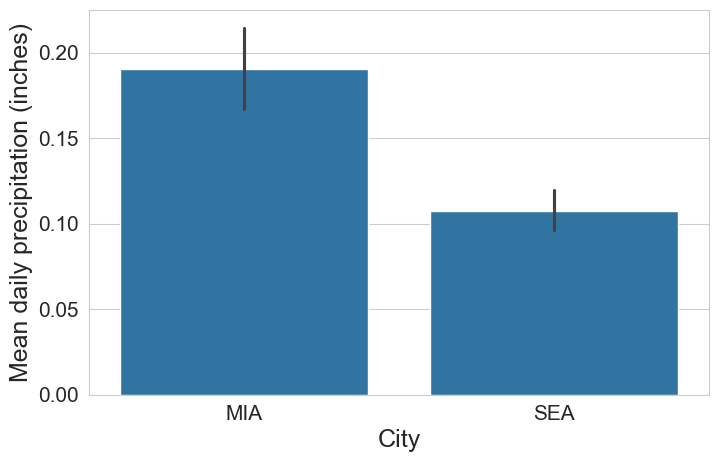

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="city", y="precipitation")
plt.xlabel("City", fontsize=18)
plt.ylabel("Mean daily precipitation (inches)", fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

The bar graph shows the same thing as the summary table: Miami has a higher mean daily precipitation than Seattle. According to the seaborn documentation for `barplot`, the error bars are 95% confidence intervals for the mean. The confidence intervals for the two cities do not overlap.

### Precipitation by month

Precipitation changes a lot with the seasons, so it makes sense to break the data down by month. I add a `month` column with the month number (1 to 12).

In [53]:
df["month"] = df["date"].dt.month

df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,MIA,0.00,1,1
1,2018-01-02,MIA,0.24,2,1
2,2018-01-03,MIA,0.50,3,1
3,2018-01-04,MIA,0.00,4,1
4,2018-01-05,MIA,0.00,5,1


I use box plots to look at the full distribution of precipitation in each month for each city.

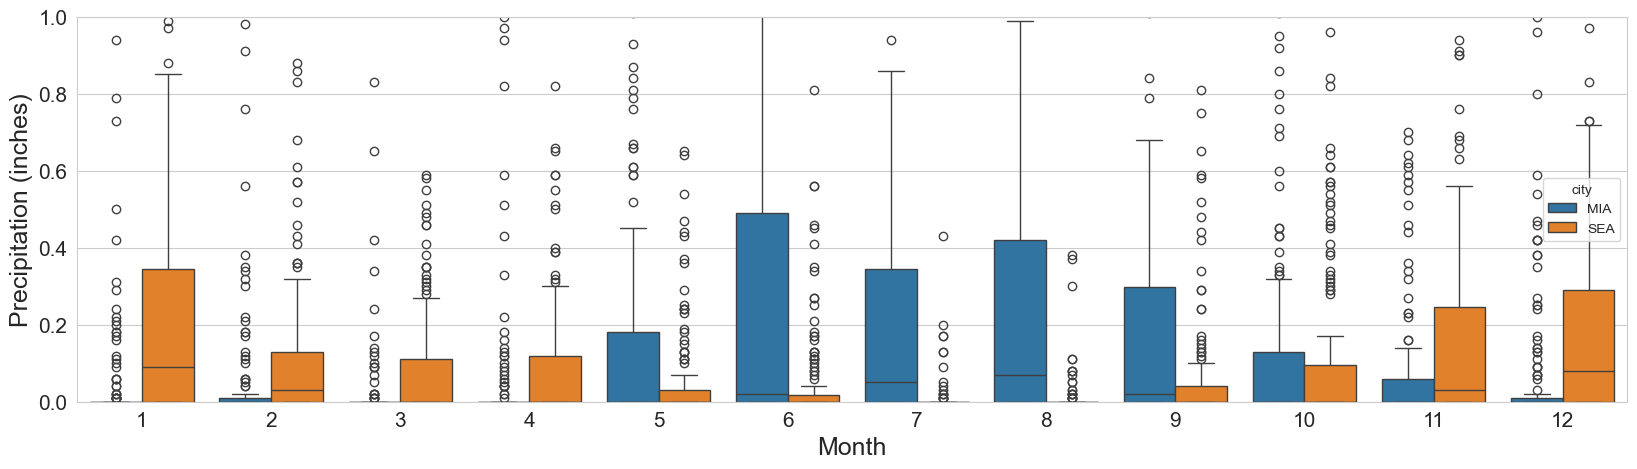

In [61]:
plt.figure(figsize=(20, 5))
sns.boxplot(data=df, x="month", y="precipitation", hue="city")
plt.ylim(0, 1)
plt.xlabel("Month", fontsize=18)
plt.ylabel("Precipitation (inches)", fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

In the winter months the Seattle boxes are wider, and in the summer months the Miami boxes are much wider.

From November to April, Seattle's boxes are higher than Miami's, so Seattle usually gets more rain in the winter. From May to October, Miami's boxes are much higher, which matches Miami's summer rainy season. So the answer to the question depends on the time of year.

### Mean precipitation by month

Box plots show the median and spread, so I also make a bar graph of the mean precipitation in each month.

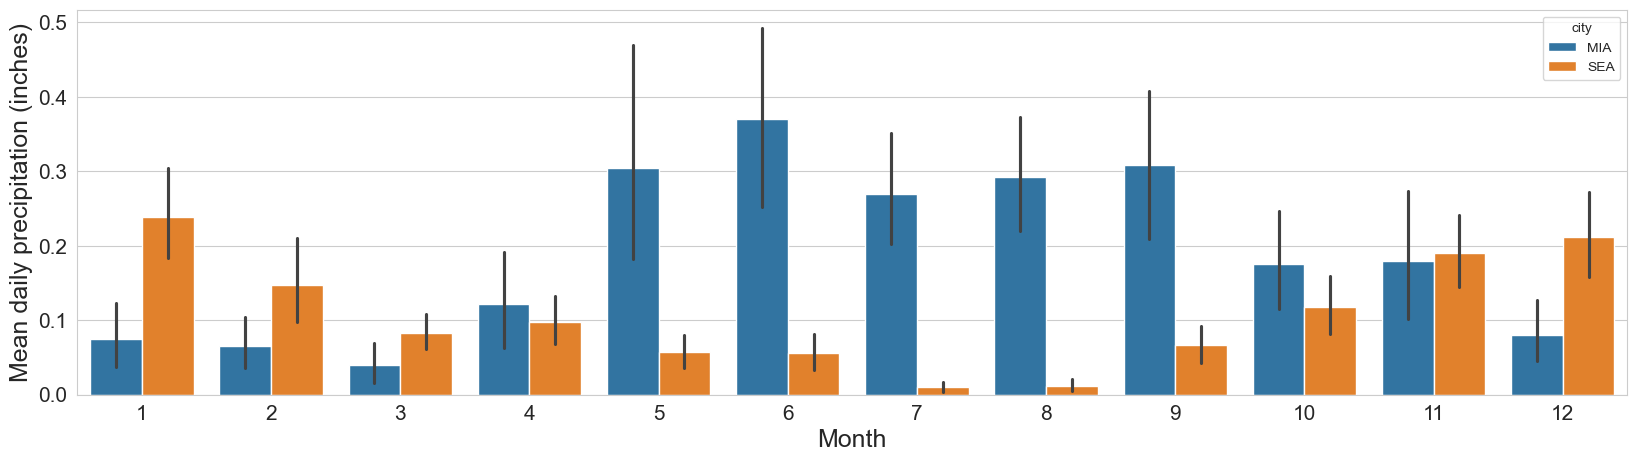

In [64]:
plt.figure(figsize=(20, 5))
sns.barplot(data=df, x="month", y="precipitation", hue="city")
plt.xlabel("Month", fontsize=18)
plt.ylabel("Mean daily precipitation (inches)", fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

The means show the same pattern as the box plot. Seattle has a higher mean from December through March and is slightly higher in November. Miami has a higher mean from April through October, and the difference is biggest from May to September.

Here are the mean values for each city and month.

In [67]:
df[["city", "month", "precipitation"]].groupby(["city", "month"]).mean().unstack("city").round(3)

precipitation       
city            MIA    SEA
month                     
1             0.074  0.239
2             0.066  0.148
3             0.039  0.083
4             0.122  0.098
5             0.305  0.057
6             0.370  0.056
7             0.270  0.010
8             0.292  0.012
9             0.309  0.067
10            0.176  0.118
11            0.179  0.190
12            0.081  0.212

Seattle's highest mean is in January (0.239 inches per day) and its lowest is in July (0.010 inches per day). Miami's highest mean is in June (0.370 inches per day) and its lowest is in March (0.039 inches per day). In July and August, Miami gets more than 20 times as much rain per day as Seattle.

### How often does it rain?

The amount of rain is only one way to think about the question. Seattle's reputation might come from how often it rains rather than how much. I add a new column called `any_precipitation` that is `True` if there was any precipitation that day and `False` if there was none.

In [70]:
df["any_precipitation"] = df["precipitation"] > 0

df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,MIA,0.00,1,1,False
1,2018-01-02,MIA,0.24,2,1,True
2,2018-01-03,MIA,0.50,3,1,True
3,2018-01-04,MIA,0.00,4,1,False
4,2018-01-05,MIA,0.00,5,1,False


I calculate the proportion of days with any precipitation for each city.

In [72]:
df[["city", "any_precipitation"]].groupby("city").mean()

,any_precipitation
city,
MIA,0.411281
SEA,0.425520


Seattle had precipitation on about 42.6% of days and Miami had precipitation on about 41.1% of days. So even though Miami gets a lot more rain in total, the two cities have rain on almost the same fraction of days. This means that when it rains in Miami, it usually rains a lot more than in Seattle.

I also look at the proportion of days with precipitation in each month.

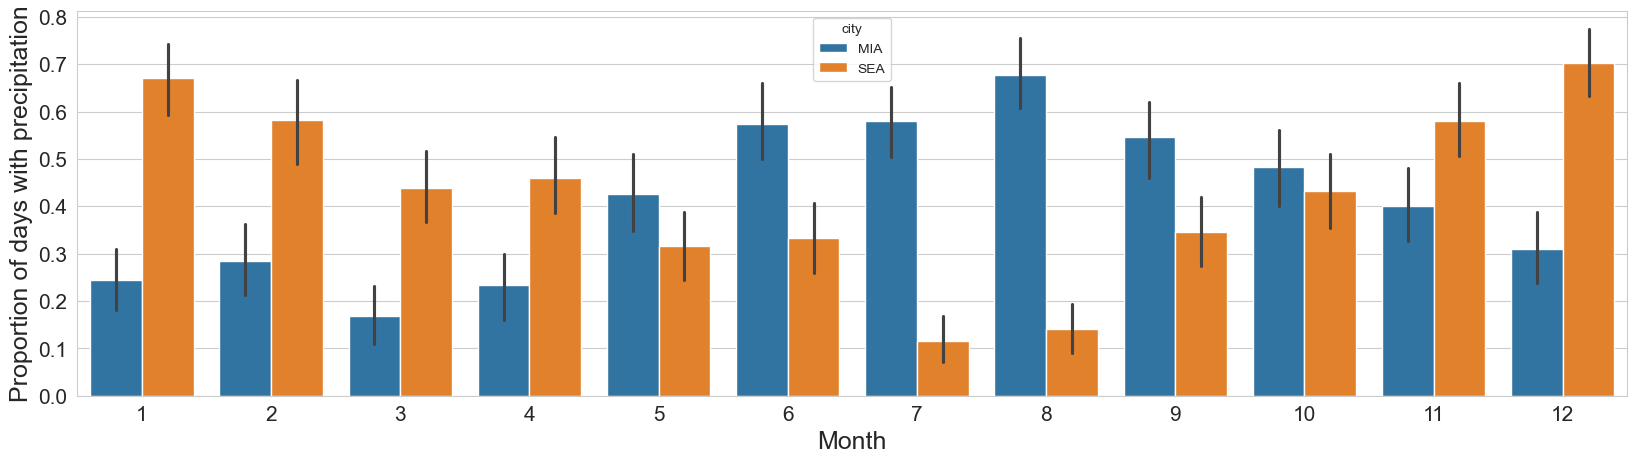

In [75]:
plt.figure(figsize=(20, 5))
sns.barplot(data=df, x="month", y="any_precipitation", hue="city")
plt.xlabel("Month", fontsize=18)
plt.ylabel("Proportion of days with precipitation", fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

This graph shows a big difference between the seasons. In December and January, Seattle has precipitation on about 70% of days, compared to about 25 to 30% in Miami. In the summer it flips. In August, Miami has precipitation on about 68% of days and Seattle only about 14%.

## Statistical Tests

### Comparing mean precipitation each month

Disclaimer: AI aided - limited knowledge about statistical tests in Python - used AI to learn about the syntax and methods

From the graphs, it looks like there are differences in the mean precipitation between the cities in most months. To check whether these differences are statistically significant, I want to use a t-test for each month.

One assumption of the t-test is that the data come from normal distributions. I check this by making histograms of the precipitation in each city for January.

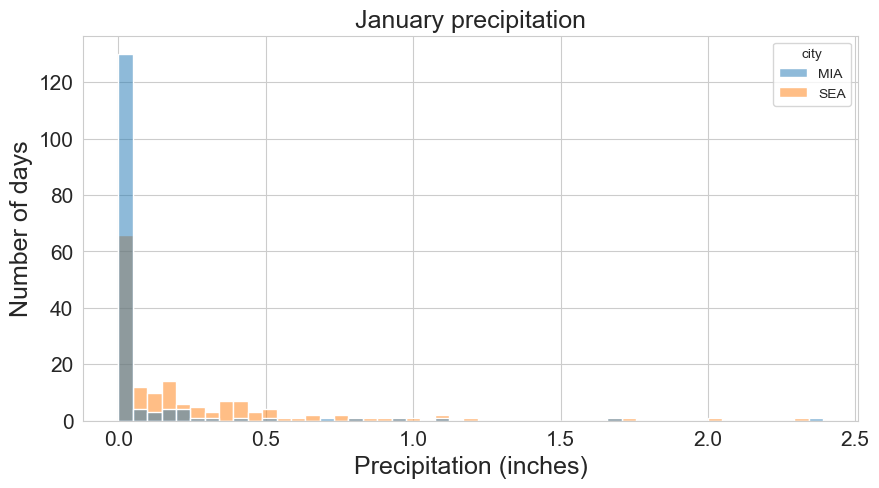

In [78]:
january = df[df["month"] == 1]

plt.figure(figsize=(10, 5))
sns.histplot(data=january, x="precipitation", hue="city")
plt.xlabel("Precipitation (inches)", fontsize=18)
plt.ylabel("Number of days", fontsize=18)
plt.title("January precipitation", fontsize=18)
plt.tick_params(labelsize=15)
plt.show()

The histograms are not normal. They are very skewed to the right, because most days have little or no rain and a few days have a lot. However, each city has about 150 days of data for each month (about 30 days times 5 years). With this many observations, the t-test still works as an approximate test, so I will use it.

I run an independent samples t-test for each month using a significance level of 0.05. I keep track of which months are significantly different by storing a 1 for those months in the `significantly_different` array.

In [81]:
alpha = 0.05
significantly_different = np.zeros(12)

for month in range(1, 13):
    seattle_data = df.loc[(df["city"] == "SEA") & (df["month"] == month), "precipitation"]
    miami_data = df.loc[(df["city"] == "MIA") & (df["month"] == month), "precipitation"]

    t_statistic, p_value = stats.ttest_ind(seattle_data, miami_data)

    if p_value < alpha:
        significantly_different[month - 1] = 1

    print(f"Month {month}: t = {t_statistic:.3f}, p-value = {p_value:.4f}")

Month 1: t = 4.329, p-value = 0.0000
Month 2: t = 2.445, p-value = 0.0151
Month 3: t = 2.471, p-value = 0.0140
Month 4: t = -0.696, p-value = 0.4872
Month 5: t = -3.582, p-value = 0.0004
Month 6: t = -4.932, p-value = 0.0000
Month 7: t = -6.904, p-value = 0.0000
Month 8: t = -7.091, p-value = 0.0000
Month 9: t = -4.689, p-value = 0.0000
Month 10: t = -1.499, p-value = 0.1350
Month 11: t = 0.209, p-value = 0.8345
Month 12: t = 3.553, p-value = 0.0004


A positive t statistic means Seattle had the higher mean, and a negative t statistic means Miami had the higher mean. The difference is significant in 9 of the 12 months. Seattle has a significantly higher mean in January, February, March, and December. Miami has a significantly higher mean in May, June, July, August, and September. April, October, and November are not significantly different.

I add a star above each month on the bar graph where the difference is significant.

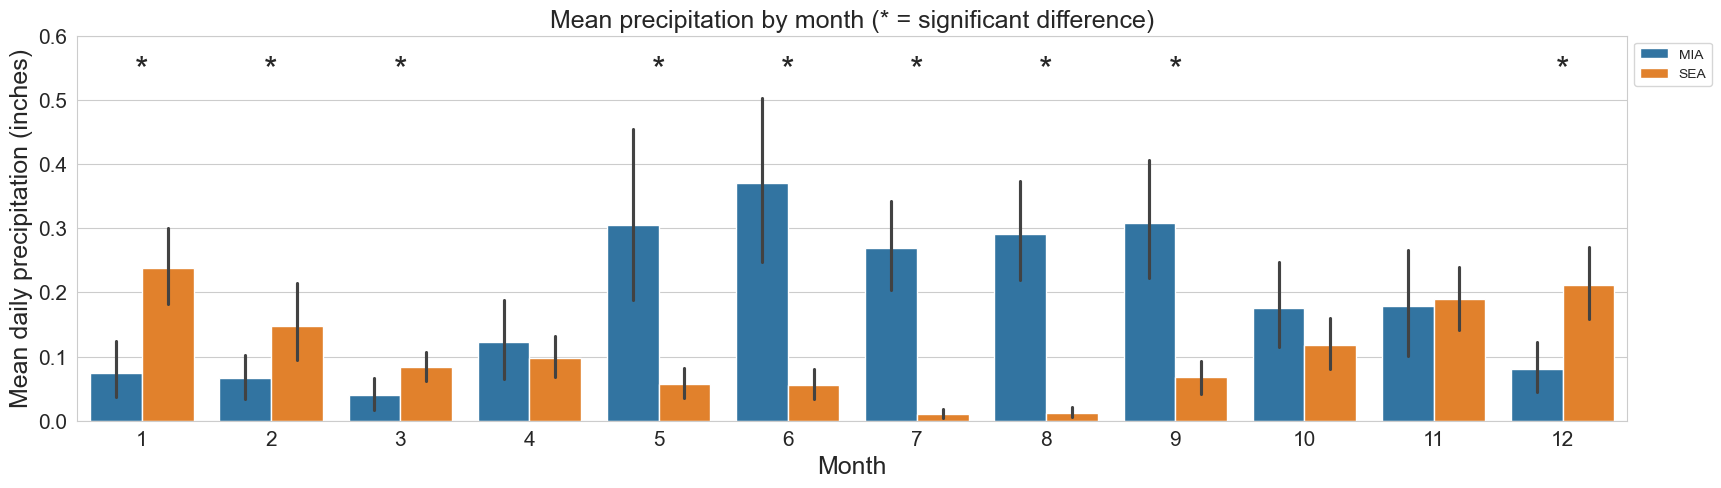

In [84]:
plt.figure(figsize=(20, 5))
sns.barplot(data=df, x="month", y="precipitation", hue="city")

for month in range(1, 13):
    if significantly_different[month - 1] == 1:
        plt.text(month - 1, 0.53, "*", ha="center", fontsize=25)

plt.ylim(0, 0.6)
plt.xlabel("Month", fontsize=18)
plt.ylabel("Mean daily precipitation (inches)", fontsize=18)
plt.title("Mean precipitation by month (* = significant difference)", fontsize=18)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tick_params(labelsize=15)
plt.show()

The stars make it easy to see that Seattle gets significantly more rain in the winter, Miami gets significantly more in the summer, and the months in between are not significantly different.

## Comparing the proportion of days with precipitation each month

Next I test whether the proportion of days with any precipitation is different between the two cities in each month. To compare two proportions I use a proportions z-test.

In [90]:
alpha = 0.05
proportion_significantly_different = np.zeros(12)

for month in range(1, 13):
    month_data = df[df["month"] == month]
    table = pd.crosstab(month_data["city"], month_data["any_precipitation"])

    days_with_precipitation = [table.loc["SEA", True], table.loc["MIA", True]]
    total_days = [table.loc["SEA"].sum(), table.loc["MIA"].sum()]

    z_statistic, p_value = proportions_ztest(days_with_precipitation, total_days)

    if p_value < alpha:
        proportion_significantly_different[month - 1] = 1

    print(f"Month {month}: z = {z_statistic:.3f}, p-value = {p_value:.4f}")

Month 1: z = 7.524, p-value = 0.0000
Month 2: z = 5.048, p-value = 0.0000
Month 3: z = 5.190, p-value = 0.0000
Month 4: z = 4.125, p-value = 0.0000
Month 5: z = -1.999, p-value = 0.0456
Month 6: z = -4.175, p-value = 0.0000
Month 7: z = -8.583, p-value = 0.0000
Month 8: z = -9.586, p-value = 0.0000
Month 9: z = -3.484, p-value = 0.0005
Month 10: z = -0.912, p-value = 0.3618
Month 11: z = 3.118, p-value = 0.0018
Month 12: z = 6.930, p-value = 0.0000


A positive z statistic means Seattle had precipitation on a higher proportion of days, and a negative z statistic means Miami did. The difference is significant in every month except October. Seattle has rain significantly more often from November through April, and Miami has rain significantly more often from May through September.

I add stars to the proportion graph for the months that are significantly different.

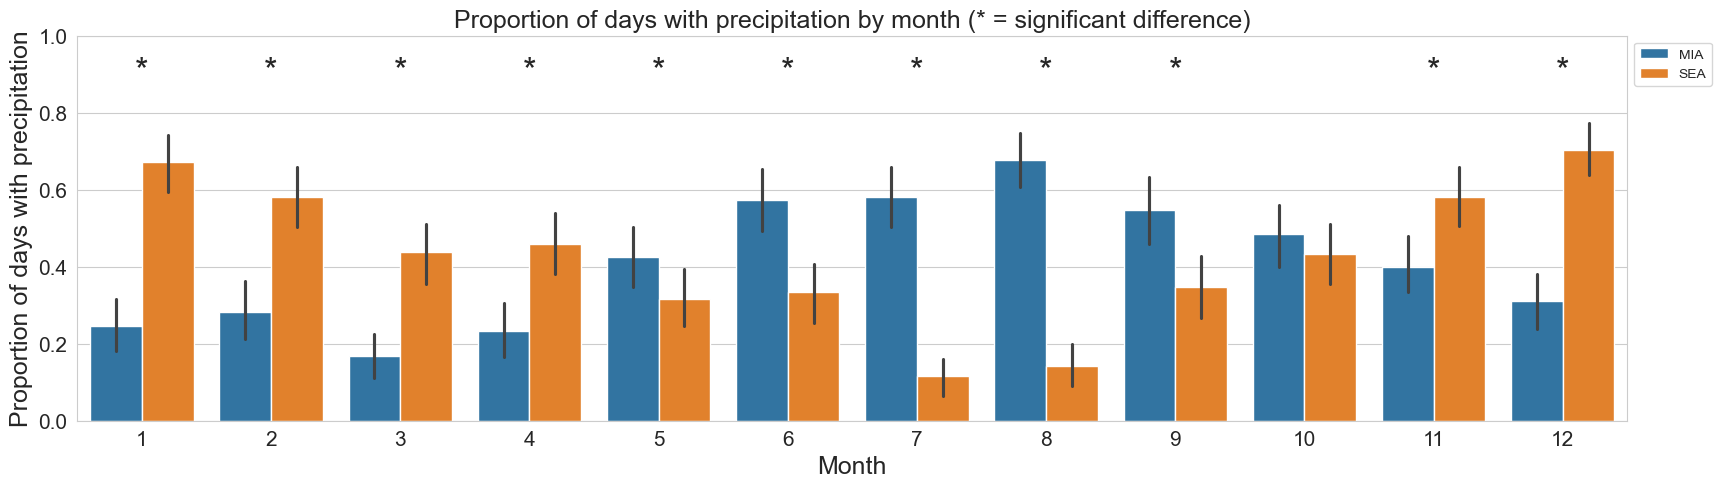

In [93]:
plt.figure(figsize=(20, 5))
sns.barplot(data=df, x="month", y="any_precipitation", hue="city")

for month in range(1, 13):
    if proportion_significantly_different[month - 1] == 1:
        plt.text(month - 1, 0.88, "*", ha="center", fontsize=25)

plt.ylim(0, 1)
plt.xlabel("Month", fontsize=18)
plt.ylabel("Proportion of days with precipitation", fontsize=18)
plt.title("Proportion of days with precipitation by month (* = significant difference)", fontsize=18)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tick_params(labelsize=15)
plt.show()

This graph shows that how often it rains is significantly different in almost every month. Seattle has rain more often for about half of the year and Miami has rain more often for the other half.

## Conclusion

Overall, it does not rain more in Seattle than in Miami. Miami gets more precipitation on average (0.19 inches per day compared to 0.11 inches per day in Seattle), and the two cities have precipitation on about the same proportion of days (about 42% in Seattle and 41% in Miami).

The answer changes depending on the season, though. In the winter months, Seattle gets significantly more rain than Miami and has rain on many more days. In the summer it is the opposite, and Miami gets much more rain and has rain more often. Miami's summer storms are also much heavier, which is why Miami's total is so much higher.

This may help explain Seattle's reputation. Seattle has rain on about two out of every three days in December and January, so it feels like it rains all the time during the winter, even though it gets less rain than Miami over the whole year.

One limitation of this analysis is that each city only uses one weather station at the airport, which may not match the weather in every part of the city. The data also only covers five years, so a longer time period would give a more reliable answer.